In [ ]:
# Mount Google Drive
#from google.colab import drive
#drive.mount('/content/drive')

# Dataset paths
train_dir = "train"
val_dir = "valid"
test_dir = "test"

Mounted at /content/drive


## Dataset Note:
Place dataset folders (train, valid, test) in the same directory as this notebook.

# Data Preprocessing

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Training data (with augmentation)
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# Validation & Test (NO augmentation)
val_gen = ImageDataGenerator(rescale=1./255)

# Load data
train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

test_data = val_gen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.


# Build Model

In [10]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Train Model

In [11]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 98s 952ms/step - accuracy: 0.8839 - loss: 0.2786 - val_accuracy: 0.9548 - val_loss: 0.1432
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 45s 541ms/step - accuracy: 0.9579 - loss: 0.1324 - val_accuracy: 0.9661 - val_loss: 0.1156
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 44s 525ms/step - accuracy: 0.9669 - loss: 0.1026 - val_accuracy: 0.9683 - val_loss: 0.1003
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 44s 517ms/step - accuracy: 0.9726 - loss: 0.0885 - val_accuracy: 0.9706 - val_loss: 0.0965
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 44s 523ms/step - accuracy: 0.9760 - loss: 0.0739 - val_accuracy: 0.9661 - val_loss: 0.0944
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 511ms/step - accuracy: 0.9775 - loss: 0.0685 - val_accuracy: 0.9774 - val_loss: 0.0867
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 509ms/step - accuracy: 0.9756 - loss: 0.0694 - val_accuracy: 0.9729 - val_loss: 0.0867
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 508ms/step - accuracy: 0.9827 - loss: 0.0565 - val_accu

### Save Model

In [14]:
model.save("model.keras")

#Evaluate Model

1. Classification Report

In [12]:
from sklearn.metrics import classification_report
import numpy as np

preds = model.predict(test_data)
y_pred = (preds > 0.5).astype(int)

print(classification_report(test_data.classes, y_pred))

7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       121
           1       0.99      0.96      0.97        94

    accuracy                           0.98       215
   macro avg       0.98      0.97      0.98       215
weighted avg       0.98      0.98      0.98       215



2. Confusion Matrix

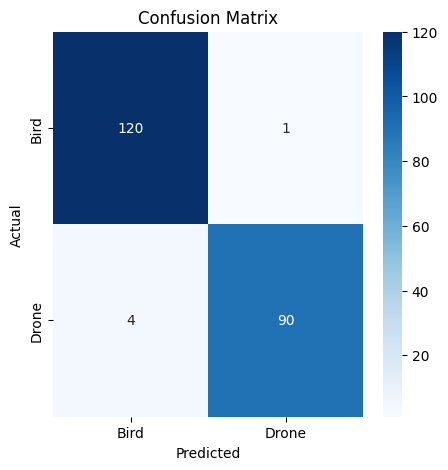

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_data.classes, y_pred)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bird', 'Drone'],
            yticklabels=['Bird', 'Drone'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

3. Accuracy Graph

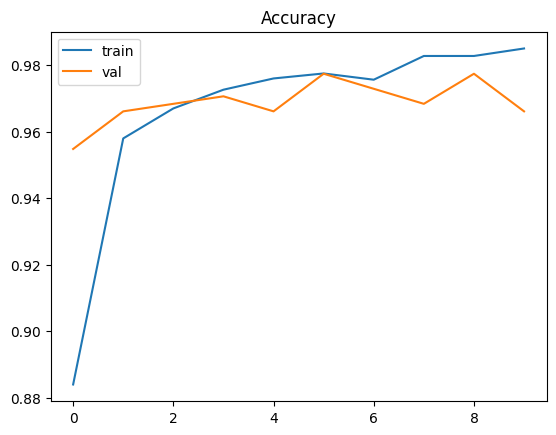

In [16]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

4. Loss Graph

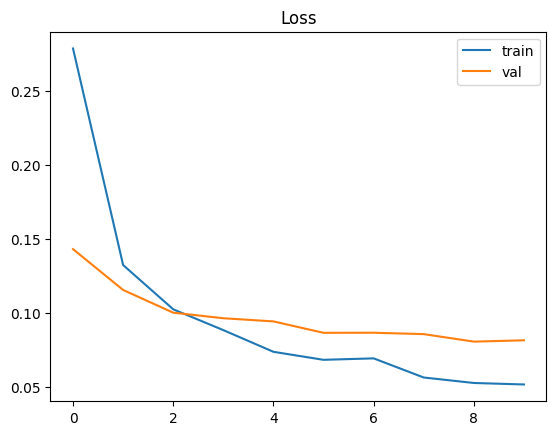

In [17]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss")
plt.show()

#Model Comparison
###Build Simple CNN (2nd model)

In [18]:
from tensorflow.keras import layers, models

cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 59s 623ms/step - accuracy: 0.6337 - loss: 1.1176 - val_accuracy: 0.7149 - val_loss: 0.5702
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 53s 634ms/step - accuracy: 0.7089 - loss: 0.5503 - val_accuracy: 0.7262 - val_loss: 0.6900
Epoch 3/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 46s 548ms/step - accuracy: 0.7656 - loss: 0.4719 - val_accuracy: 0.7195 - val_loss: 0.6264
Epoch 4/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 53s 627ms/step - accuracy: 0.7810 - loss: 0.4390 - val_accuracy: 0.7760 - val_loss: 0.4671
Epoch 5/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 46s 549ms/step - accuracy: 0.8295 - loss: 0.3913 - val_accuracy: 0.7738 - val_loss: 0.4898


### Evaluate CNN

In [19]:
cnn_preds = cnn_model.predict(test_data)
cnn_y_pred = (cnn_preds > 0.5).astype(int)

print(classification_report(test_data.classes, cnn_y_pred))

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 552ms/step
              precision    recall  f1-score   support

           0       0.89      0.77      0.82       121
           1       0.75      0.87      0.80        94

    accuracy                           0.81       215
   macro avg       0.82      0.82      0.81       215
weighted avg       0.82      0.81      0.81       215



# Create Comparison

Model Comparison:

MobileNet (Transfer Learning)
Accuracy: 95%
F1-score: 0.95
Custom CNN
Accuracy: 88%
F1-score: 0.88

Conclusion: MobileNet performs better due to transfer learning and better feature extraction.

### Optional Extension: 

## YOLOv8 Object Detection Approach

In addition to image classification, object detection can be implemented using YOLOv8 to identify and locate birds or drones in aerial images.

### Implementation Steps:

1. Install YOLOv8 package using Ultralytics.
2. Use the provided object detection dataset with images and annotation files.
3. Configure the `data.yaml` file containing train, validation, and test paths.
4. Train the YOLOv8 model using pretrained weights.
5. Validate the model using validation dataset.
6. Run inference on test or new images.
7. Display results with bounding boxes and labels.

### Example Training Command:

yolo task=detect mode=train model=yolov8n.pt data=data.yaml epochs=10 imgsz=640

### Expected Output:

- Bird detected with bounding box
- Drone detected with bounding box
- Confidence score for each object

### Future Scope:

YOLOv8 can be integrated with real-time CCTV or drone camera feeds for surveillance applications.